In [5]:
# netPCF import
import spacenet as sn

# other imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import networkx as nx
import sknetwork as skn
import seaborn as sns


np.random.seed(6)

plt.rcParams['figure.dpi'] = 200
edge_width=0.5

visualise_paras = dict(edge_width=1,marker_size=15,edge_weight_name=None,add_node_cbar=False,scatter_kwargs={'linewidth':0.1,'edgecolor':'k'})

# running the partitioning over different numbers of partitions
number_of_partitions = [4,9,11,15]

partition_paramters = dict(distance_attr='Distance',
    alpha=0.65,  # large gamma to hit equal-volume target harder , smaller gamma for more compact
    p=2,        # squared distances for tighter clusters
    max_iter=15,
    random_seed=0)

# load in synthetic data
points = np.loadtxt('../data/synthetic_data/points_ppp.csv',delimiter=',')
points_with_holes_removed = np.loadtxt('../data/synthetic_data/points_ppp_with_holes.csv',delimiter=',')
points_with_holes_removed_with_clusters = np.loadtxt('../data/synthetic_data/points_ppp_with_holes_and_clusters.csv',delimiter=',')

spiral_df = pd.read_csv('../data/synthetic_data/spiral_domain.csv')
points_spiral = spiral_df[['x','y']].to_numpy() 
points_spiral= (points_spiral/2 + 500) +np.array([-25,50])


def compute_community_radius(G, partition):
    community_radii = {}
    for community in set(partition.labels.values()):
        nodes_in_community = [node for node, label in partition.labels.items() if label == community]
        subgraph = G.subgraph(nodes_in_community)
        sub_diameter = nx.diameter(subgraph, weight='Distance') 
        this_medoid = partition.medoids[community]
        distances = nx.single_source_dijkstra_path_length(subgraph, this_medoid, weight='Distance')
        distance_as_array = np.array(list(distances.values()))  
        community_radii[community] = (2*np.max(distance_as_array) - sub_diameter) / subgraph.size(weight='Distance')
        
    return community_radii  

Text(0.5, 0, 'x')

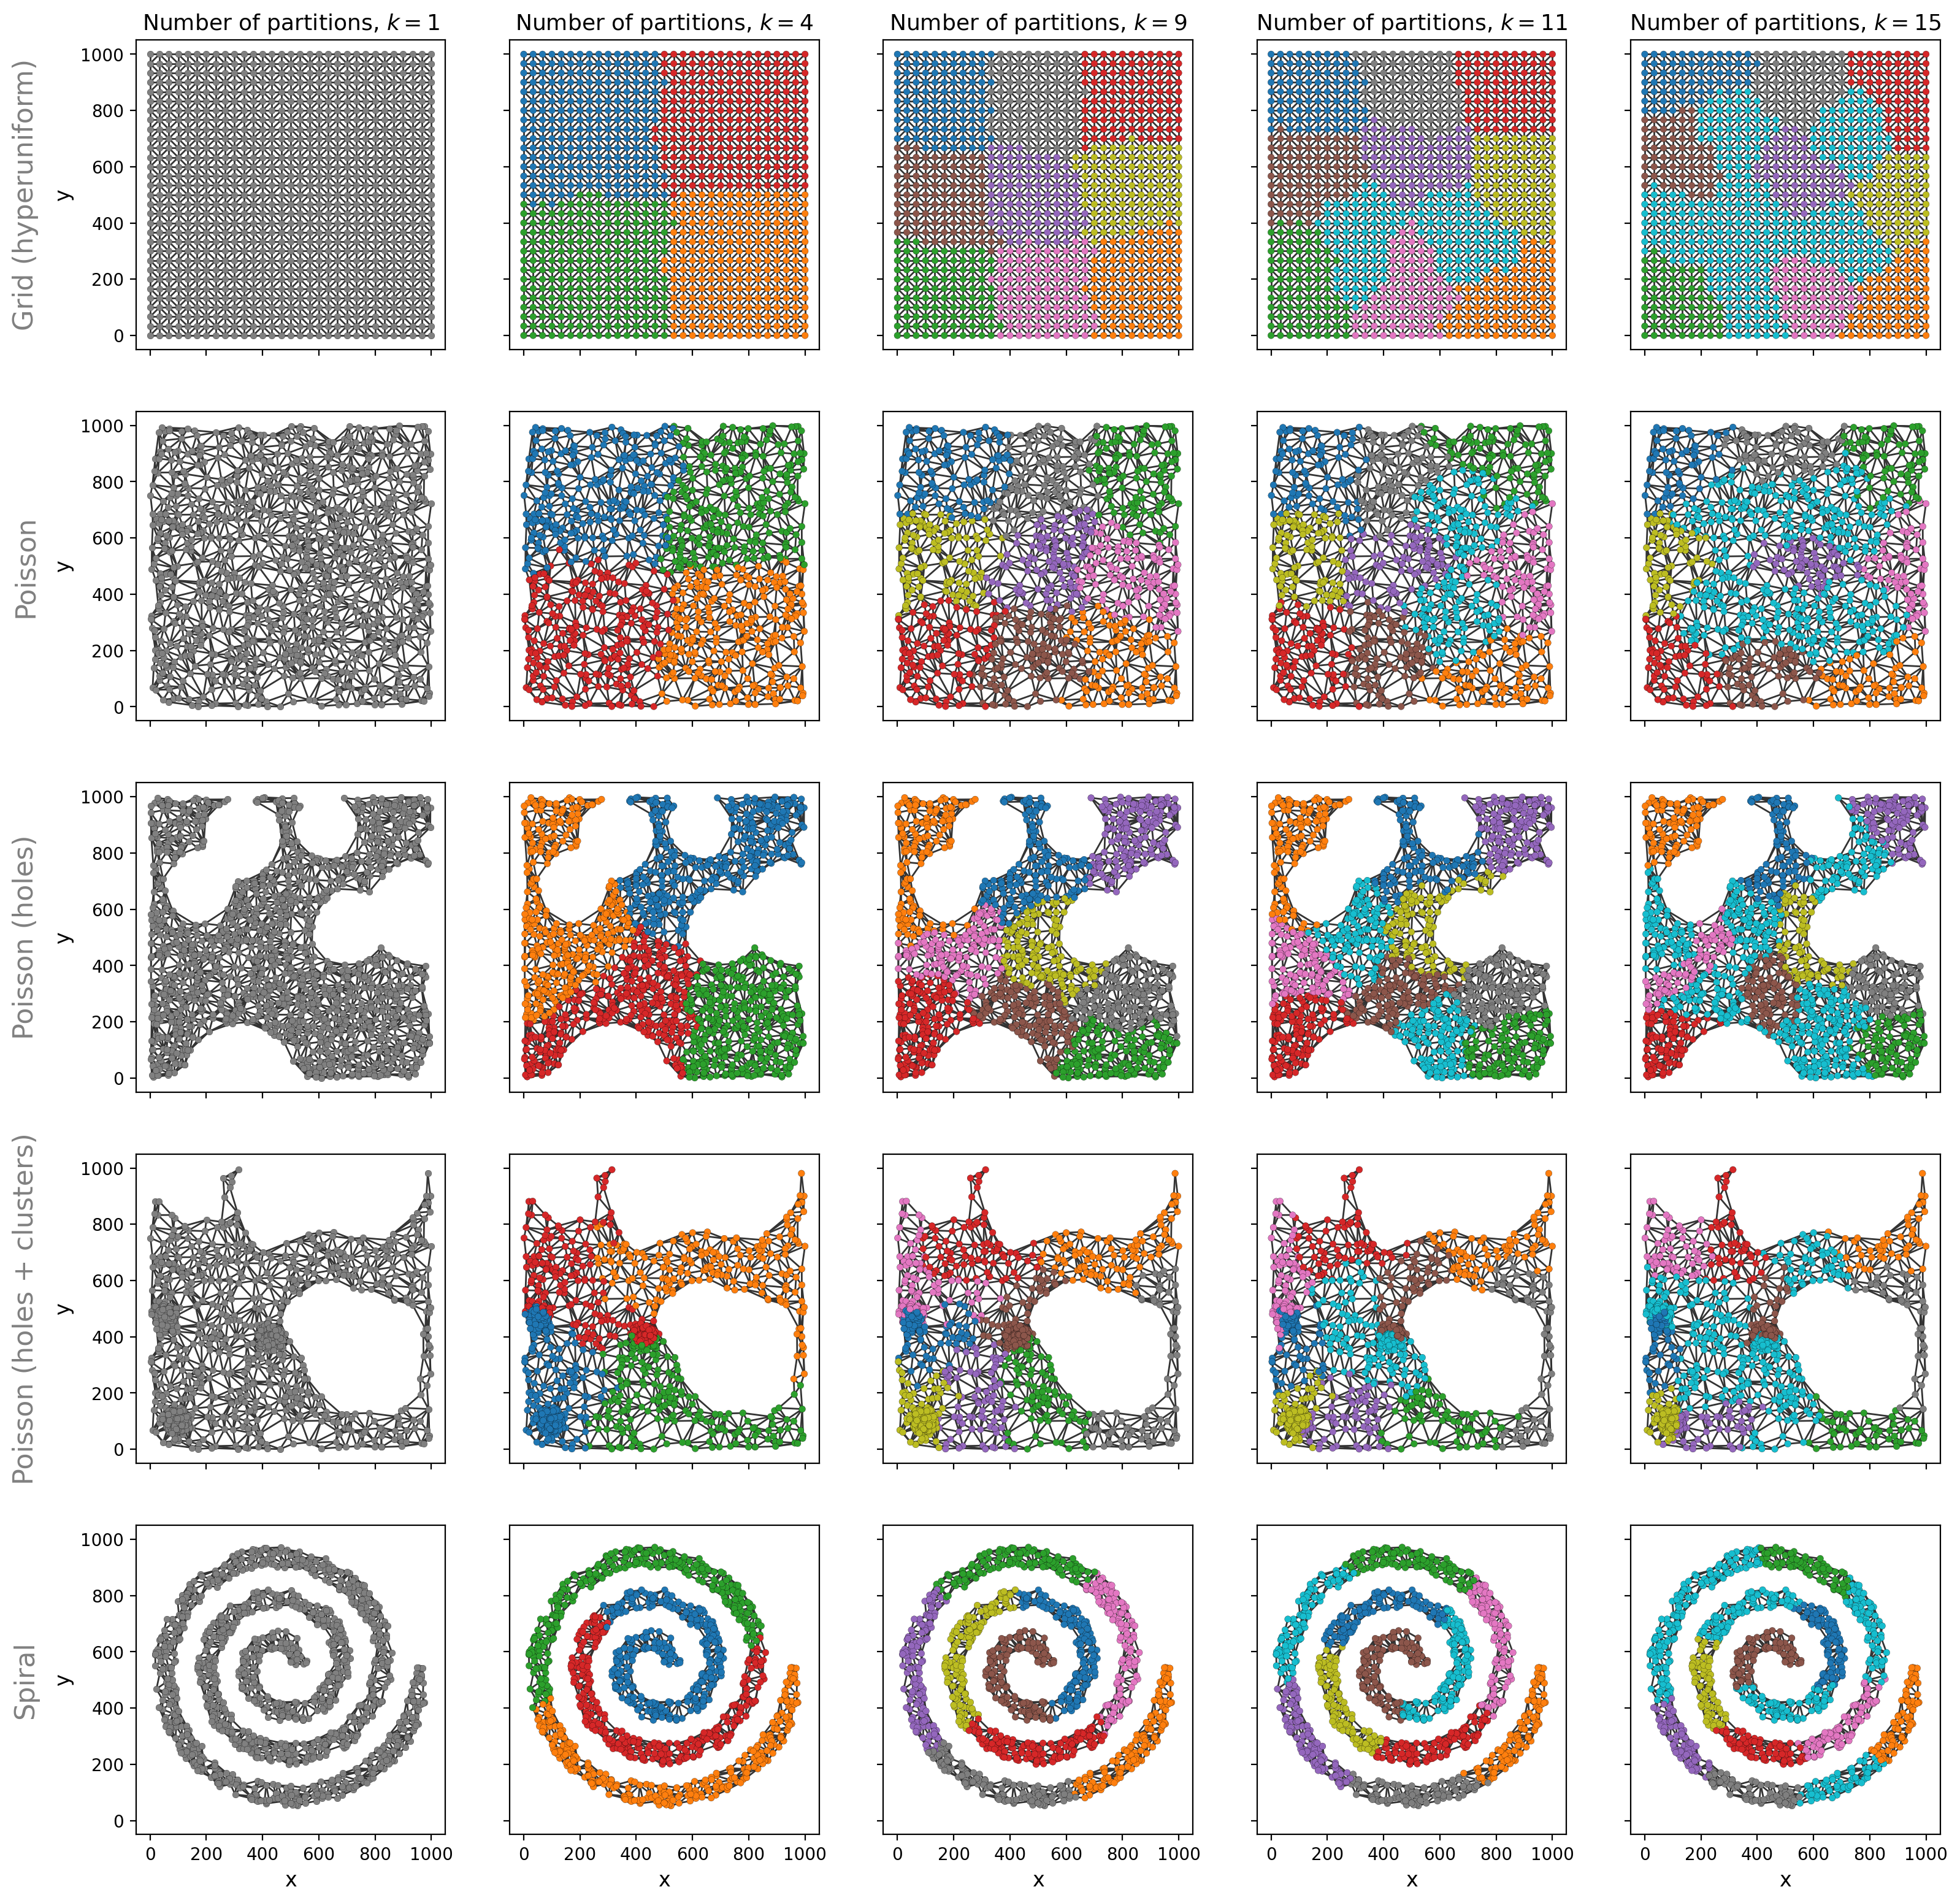

In [6]:

target_test_ratio = dict()
target_test_ratio['Grid'] = dict()
target_test_ratio['PPP'] = dict()
target_test_ratio['PPP holes'] = dict()
target_test_ratio['PPP holes clusters'] = dict()
target_test_ratio['Spiral'] = dict()

# initalise a domain

fig,ax=plt.subplots(5,1+len(number_of_partitions),figsize=(3.8*(1+len(number_of_partitions)), 3.8*5),sharex=True,sharey=True)

##### Grid ######
lambda_points=0.001  # point density
num_points = int(1000 * 1000 * lambda_points)

grid_size = int(np.sqrt(num_points))  # Assuming a square grid
x = np.linspace(0, 1000, grid_size)
y = np.linspace(0, 1000, grid_size)
points_grid = np.array(np.meshgrid(x, y)).T.reshape(-1, 2)

G0 = sn.utils.spatial_network_from_points(points_grid,network_type='Delaunay',max_edge_distance=100)
total_length_0 = G0.size(weight='Distance')
#diameter_0 = nx.diameter(G0, weight='Distance')

for i,this_k in enumerate(number_of_partitions):
    this_target_length = total_length_0 / this_k   
    network_partitions_0_1 = sn.partition.compact_volume_partition(G0, T=this_target_length, k=this_k, **partition_paramters)
    target_test_ratio['Grid'][this_k] = dict()
    target_test_ratio['Grid'][this_k]['Error'] = ((np.array(list(network_partitions_0_1.community_volumes.values())) - this_target_length) / this_target_length)*100
    target_test_ratio['Grid'][this_k]['Variance'] = np.var(np.array(list(network_partitions_0_1.community_volumes.values())))
    target_test_ratio['Grid'][this_k]['Values'] = np.array(list(network_partitions_0_1.community_volumes.values()))
    target_test_ratio['Grid'][this_k]['convergence'] = np.array(network_partitions_0_1.objective_values)
    target_test_ratio['Grid'][this_k]['conductance'] = np.array(list(network_partitions_0_1.community_cut_lengths.values())) / np.array(list(network_partitions_0_1.community_volumes.values()))
    target_test_ratio['Grid'][this_k]['cut'] = np.array(list(network_partitions_0_1.community_cut_lengths.values()))
    target_test_ratio['Grid'][this_k]['community_radii'] = np.array(list(compute_community_radius(G0, network_partitions_0_1).values())) 
    
    # visualise the partition - labels matched to the order of the points
    labels = np.array(list(network_partitions_0_1.labels.values()))
    labels_reordered = labels[np.argsort(np.array(list(network_partitions_0_1.labels.keys())))]
    
    sn.utils.add_node_labels(G0,labels_reordered,'part_labels')
    sn.utils.plot_spatial_network(G0,node_label_name='part_labels',ax=ax[0,i+1],**visualise_paras)
    
# visualise
sn.utils.plot_spatial_network(G0,ax=ax[0,0],**visualise_paras)


### PPP ######
G1 = sn.utils.spatial_network_from_points(points,network_type='Delaunay',max_edge_distance=100)
total_length_1 = G1.size(weight='Distance')
#diameter_1 = nx.diameter(G1, weight='Distance')

for i,this_k in enumerate(number_of_partitions):
    this_target_length = total_length_1 / this_k   
    network_partitions_1_1 = sn.partition.compact_volume_partition(G1, T=this_target_length, k=this_k, **partition_paramters)
    target_test_ratio['PPP'][this_k] = dict()
    target_test_ratio['PPP'][this_k]['Error'] = ((np.array(list(network_partitions_1_1.community_volumes.values())) - this_target_length) / this_target_length)*100
    target_test_ratio['PPP'][this_k]['Variance'] = np.var(np.array(list(network_partitions_1_1.community_volumes.values())))
    target_test_ratio['PPP'][this_k]['Values'] = np.array(list(network_partitions_1_1.community_volumes.values()))
    target_test_ratio['PPP'][this_k]['convergence'] = np.array(network_partitions_1_1.objective_values)
    target_test_ratio['PPP'][this_k]['conductance'] = np.array(list(network_partitions_1_1.community_cut_lengths.values())) / np.array(list(network_partitions_1_1.community_volumes.values()))
    target_test_ratio['PPP'][this_k]['cut'] = np.array(list(network_partitions_1_1.community_cut_lengths.values()))
    target_test_ratio['PPP'][this_k]['community_radii'] = np.array(list(compute_community_radius(G1, network_partitions_1_1).values())) 
    # visualise the partition - labels matched to the order of the points
    labels = np.array(list(network_partitions_1_1.labels.values()))
    labels_reordered = labels[np.argsort(np.array(list(network_partitions_1_1.labels.keys())))]

    sn.utils.add_node_labels(G1,labels_reordered,'part_labels')
    sn.utils.plot_spatial_network(G1,node_label_name='part_labels',ax=ax[1,i+1],**visualise_paras)
    
# visualise
sn.utils.plot_spatial_network(G1,ax=ax[1,0],**visualise_paras)


######  Points with holes removed ######

G2 = sn.utils.spatial_network_from_points(points_with_holes_removed,network_type='Delaunay',max_edge_distance=100)
total_length_2 = G2.size(weight='Distance')
#diameter_2 = nx.diameter(G2, weight='Distance')

for i,this_k in enumerate(number_of_partitions):
    this_target_length = total_length_2 / this_k   
    network_partitions_2_1 = sn.partition.compact_volume_partition(G2, T=this_target_length, k=this_k, **partition_paramters)
    target_test_ratio['PPP holes'][this_k] = dict()
    target_test_ratio['PPP holes'][this_k]['Error'] = ((np.array(list(network_partitions_2_1.community_volumes.values())) - this_target_length) / this_target_length)*100
    target_test_ratio['PPP holes'][this_k]['Variance'] = np.var(np.array(list(network_partitions_2_1.community_volumes.values())))
    target_test_ratio['PPP holes'][this_k]['Values'] = np.array(list(network_partitions_2_1.community_volumes.values()))
    target_test_ratio['PPP holes'][this_k]['convergence'] = np.array(network_partitions_2_1.objective_values)
    target_test_ratio['PPP holes'][this_k]['conductance'] = np.array(list(network_partitions_2_1.community_cut_lengths.values())) / np.array(list(network_partitions_2_1.community_volumes.values()))
    target_test_ratio['PPP holes'][this_k]['cut'] = np.array(list(network_partitions_2_1.community_cut_lengths.values()))
    target_test_ratio['PPP holes'][this_k]['community_radii'] = np.array(list(compute_community_radius(G2, network_partitions_2_1).values())) 
    
    # visualise the partition - labels matched to the order of the points
    labels = np.array(list(network_partitions_2_1.labels.values()))
    labels_reordered = labels[np.argsort(np.array(list(network_partitions_2_1.labels.keys())))]

    sn.utils.add_node_labels(G2,labels_reordered,'part_labels')
    sn.utils.plot_spatial_network(G2,node_label_name='part_labels',ax=ax[2,i+1],**visualise_paras)

# visualise
sn.utils.plot_spatial_network(G2,ax=ax[2,0],**visualise_paras)


######  Points with holes and clusters ######

G3 = sn.utils.spatial_network_from_points(points_with_holes_removed_with_clusters,network_type='Delaunay',max_edge_distance=100)
total_length_3 = G3.size(weight='Distance')
#diameter_3 = nx.diameter(G3, weight='Distance')
for i,this_k in enumerate(number_of_partitions):
    this_target_length = total_length_3 / this_k   
    network_partitions_3_1 = sn.partition.compact_volume_partition(G3, T=this_target_length, k=this_k, **partition_paramters)
    target_test_ratio['PPP holes clusters'][this_k] = dict()
    target_test_ratio['PPP holes clusters'][this_k]['Error'] = ((np.array(list(network_partitions_3_1.community_volumes.values())) - this_target_length) / this_target_length)*100
    target_test_ratio['PPP holes clusters'][this_k]['Variance'] = np.var(np.array(list(network_partitions_3_1.community_volumes.values())))
    target_test_ratio['PPP holes clusters'][this_k]['Values'] = np.array(list(network_partitions_3_1.community_volumes.values()))
    target_test_ratio['PPP holes clusters'][this_k]['convergence'] = np.array(network_partitions_3_1.objective_values)
    target_test_ratio['PPP holes clusters'][this_k]['conductance'] = np.array(list(network_partitions_3_1.community_cut_lengths.values())) / np.array(list(network_partitions_3_1.community_volumes.values()))
    target_test_ratio['PPP holes clusters'][this_k]['cut'] = np.array(list(network_partitions_3_1.community_cut_lengths.values()))
    target_test_ratio['PPP holes clusters'][this_k]['community_radii'] = np.array(list(compute_community_radius(G3, network_partitions_3_1).values())) 
    
    # visualise the partition - labels matched to the order of the points
    labels = np.array(list(network_partitions_3_1.labels.values()))
    labels_reordered = labels[np.argsort(np.array(list(network_partitions_3_1.labels.keys())))]


    sn.utils.add_node_labels(G3,labels_reordered,'part_labels')
    sn.utils.plot_spatial_network(G3,node_label_name='part_labels',ax=ax[3,i+1],**visualise_paras)

# visualise
sn.utils.plot_spatial_network(G3,ax=ax[3,0],**visualise_paras)

#### spiral points ####

G4 = sn.utils.spatial_network_from_points(points_spiral,network_type='Delaunay',max_edge_distance=60)
total_length_4 = G4.size(weight='Distance')
#diameter_4 = nx.diameter(G4, weight='Distance')
for i,this_k in enumerate(number_of_partitions):
    this_target_length = total_length_4 / this_k   
    network_partitions_4_1 = sn.partition.compact_volume_partition(G4, T=this_target_length, k=this_k, **partition_paramters)
    target_test_ratio['Spiral'][this_k] = dict()
    target_test_ratio['Spiral'][this_k]['Error'] = ((np.array(list(network_partitions_4_1.community_volumes.values())) - this_target_length) / this_target_length)*100
    target_test_ratio['Spiral'][this_k]['Variance'] = np.var(np.array(list(network_partitions_4_1.community_volumes.values())))
    target_test_ratio['Spiral'][this_k]['Values'] = np.array(list(network_partitions_4_1.community_volumes.values()))
    target_test_ratio['Spiral'][this_k]['convergence'] = np.array(network_partitions_4_1.objective_values)
    target_test_ratio['Spiral'][this_k]['conductance'] = np.array(list(network_partitions_4_1.community_cut_lengths.values())) / np.array(list(network_partitions_4_1.community_volumes.values()))
    target_test_ratio['Spiral'][this_k]['cut'] = np.array(list(network_partitions_4_1.community_cut_lengths.values()))
    target_test_ratio['Spiral'][this_k]['community_radii'] = np.array(list(compute_community_radius(G4, network_partitions_4_1).values())) 

    # visualise the partition - labels matched to the order of the points
    labels = np.array(list(network_partitions_4_1.labels.values()))
    labels_reordered = labels[np.argsort(np.array(list(network_partitions_4_1.labels.keys())))]

    sn.utils.add_node_labels(G4,labels_reordered,'part_labels')
    sn.utils.plot_spatial_network(G4,node_label_name='part_labels',ax=ax[4,i+1],**visualise_paras)

# visualise
sn.utils.plot_spatial_network(G4,ax=ax[4,0],**visualise_paras)


for i,this_k in enumerate(number_of_partitions):
    ax[0,1+i].set_title(f'Number of partitions, $k=${this_k}',fontsize=13,color='black')  
ax[0,0].set_title(f'Number of partitions, $k=${1}',fontsize=13,color='black')  


for i, network_name in enumerate(['Grid (hyperuniform)', 'Poisson', 'Poisson (holes)', 'Poisson (holes + clusters)', 'Spiral']):
    ax[i, 0].text(-0.4, 0.5, network_name, rotation=90, verticalalignment='center', color='grey', fontsize=16, transform=ax[i, 0].transAxes)

ax[4,0].set_xlabel('x',fontsize=12,color='black')
ax[4,0].set_ylabel('y',fontsize=12,color='black')

ax[0,0].set_ylabel('y',fontsize=12,color='black')
ax[1,0].set_ylabel('y',fontsize=12,color='black')
ax[2,0].set_ylabel('y',fontsize=12,color='black')
ax[3,0].set_ylabel('y',fontsize=12,color='black')
ax[4,0].set_ylabel('y',fontsize=12,color='black')

ax[4,1].set_xlabel('x',fontsize=12,color='black')
ax[4,2].set_xlabel('x',fontsize=12,color='black')
ax[4,3].set_xlabel('x',fontsize=12,color='black')
ax[4,4].set_xlabel('x',fontsize=12,color='black')



#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/tiling_tests/figures/network_suite.png',bbox_inches='tight',dpi=300)
#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/tiling_tests/figures/network_suite.pdf',bbox_inches='tight',dpi=300)

<>:13: SyntaxWarning: invalid escape sequence '\,'
<>:13: SyntaxWarning: invalid escape sequence '\,'
/var/folders/mh/z12kkpjj6pjg5_vrjp8t1xd40000gn/T/ipykernel_26761/2136205349.py:13: SyntaxWarning: invalid escape sequence '\,'
  ax[0].set_ylabel('Scaled objective value, $\\mathcal{L} \\, /  \, T $')


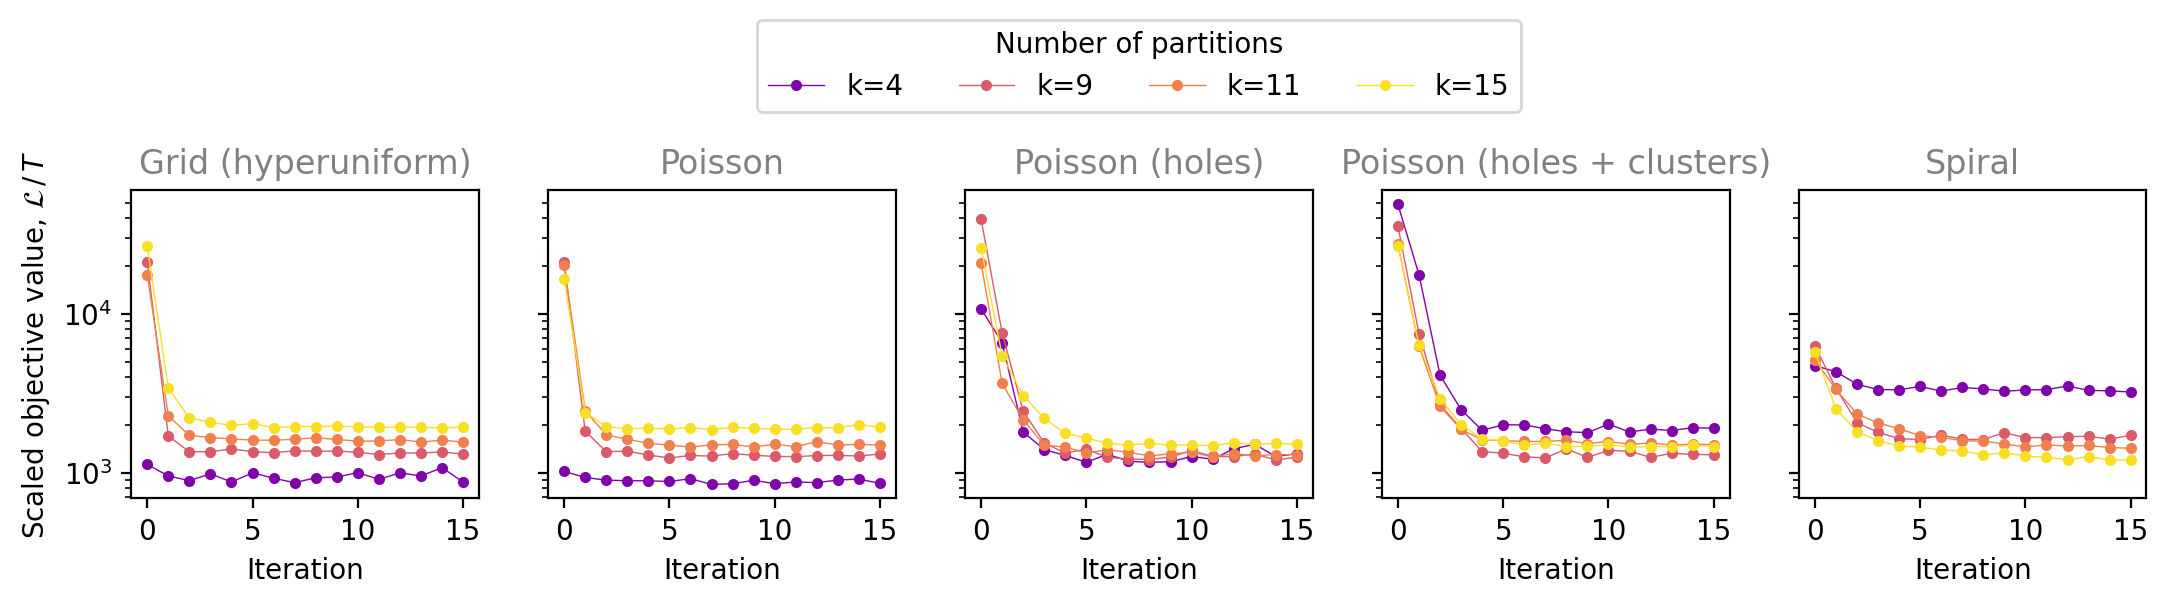

In [7]:
fig,ax=plt.subplots(1,5,figsize=(13,2),sharey=True,sharex=True)
networks = [G0,G1,G2,G3,G4]
names = ['Grid (hyperuniform)', 'Poisson', 'Poisson (holes)', 'Poisson (holes + clusters)', 'Spiral']
colors_edge= plt.cm.plasma(np.linspace(0,1,partition_paramters['max_iter']+2))
for i, test in enumerate(target_test_ratio.keys()):
    this_data = target_test_ratio[test]
    for k in number_of_partitions:
        ax[i].plot(np.arange(0,len(this_data[k]['convergence'])), this_data[k]['convergence']/ (networks[i].size(weight='Distance')/k)  , label=f'k={k}', marker='o', linewidth=0.5, markersize=3,color=colors_edge[k])  
        ax[i].set_yscale('log')
        
    ax[i].set_title(names[i],color='grey')
    ax[i].set_xlabel('Iteration')
ax[0].set_ylabel('Scaled objective value, $\\mathcal{L} \\, /  \, T $')
ax[2].legend(title='Number of partitions',loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.6), fontsize=10)
#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/tiling_tests/figures/convergence.png',bbox_inches='tight',dpi=300)
#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/tiling_tests/figures/convergence.pdf',bbox_inches='tight',dpi=300)

Text(0, 0.5, 'Scaled target partition volume \n estimation, $ (Vol(\\tilde{C}_{i})  - T) \\, / \\, Vol(G) $')

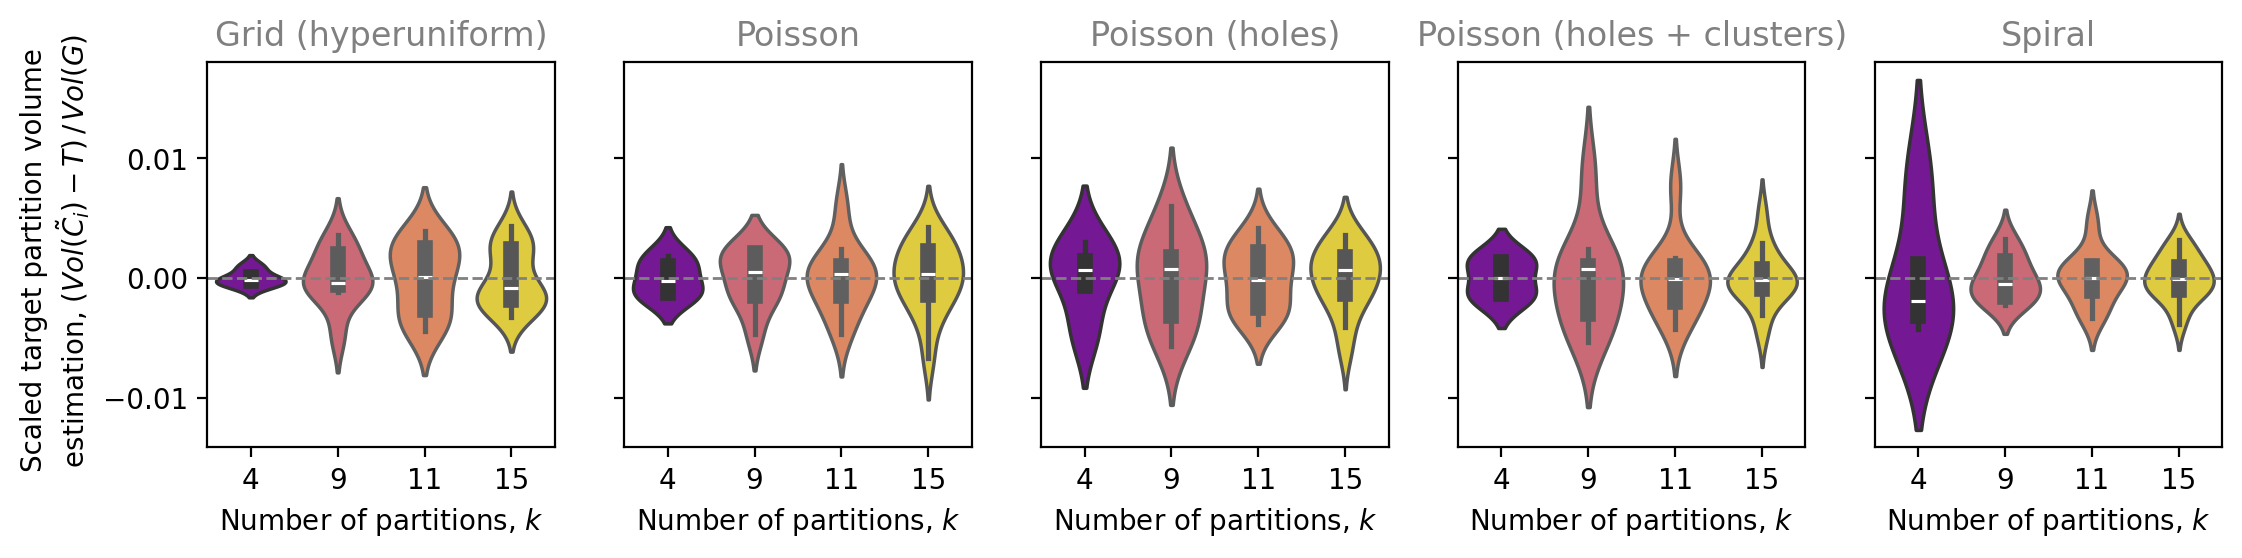

In [8]:
fig,ax=plt.subplots(1,5,figsize=(13,2.5),sharey=True,sharex=True)
networks = [G0,G1,G2,G3,G4]
names = ['Grid (hyperuniform)', 'Poisson', 'Poisson (holes)', 'Poisson (holes + clusters)', 'Spiral']
colors_edge= plt.cm.plasma(np.linspace(0,1,partition_paramters['max_iter']+2))

for i, test in enumerate(target_test_ratio.keys()):
    this_data = target_test_ratio[test]
    this_vol_dict = {}
    for j, k in enumerate(number_of_partitions):
        target_volume = networks[i].size(weight='Distance')/k
        these_volumes = this_data[k]['Values']
        these_cuts = this_data[k]['cut']
        #these_volumes_normalised = np.log(these_volumes/target_volume)
        these_volumes_normalised = (these_volumes-target_volume -these_cuts/2 ) / networks[i].size(weight='Distance')
        this_vol_dict[k] = these_volumes_normalised
        
        sns.violinplot(x=[j]*len(these_volumes_normalised), y=these_volumes_normalised, ax=ax[i], color=colors_edge[k])
    
    ax[i].set_xticks(range(len(number_of_partitions)))
    ax[i].set_xticklabels(number_of_partitions)
    ax[i].set_title(names[i],color='grey')
    #ax[i].set_ylim(-0.2,0.2)
    ax[i].set_xlabel('Number of partitions, $k$')       
    ax[i].axhline(0, color='grey', linestyle='--', linewidth=1)    
ax[0].set_ylabel('Scaled target partition volume \n estimation, $ (Vol(\\tilde{C}_{i})  - T) \\, / \\, Vol(G) $')

#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/tiling_tests/figures/partition_vol_violin.png',bbox_inches='tight',dpi=300)
#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/tiling_tests/figures/partition_vol_violin.pdf',bbox_inches='tight',dpi=300)


Text(0, 0.5, 'Scaled partition eccentricity, \n $ (2 \\epsilon(m_{j}) - diam(C_{j})) \\, / \\, Vol(G) $')

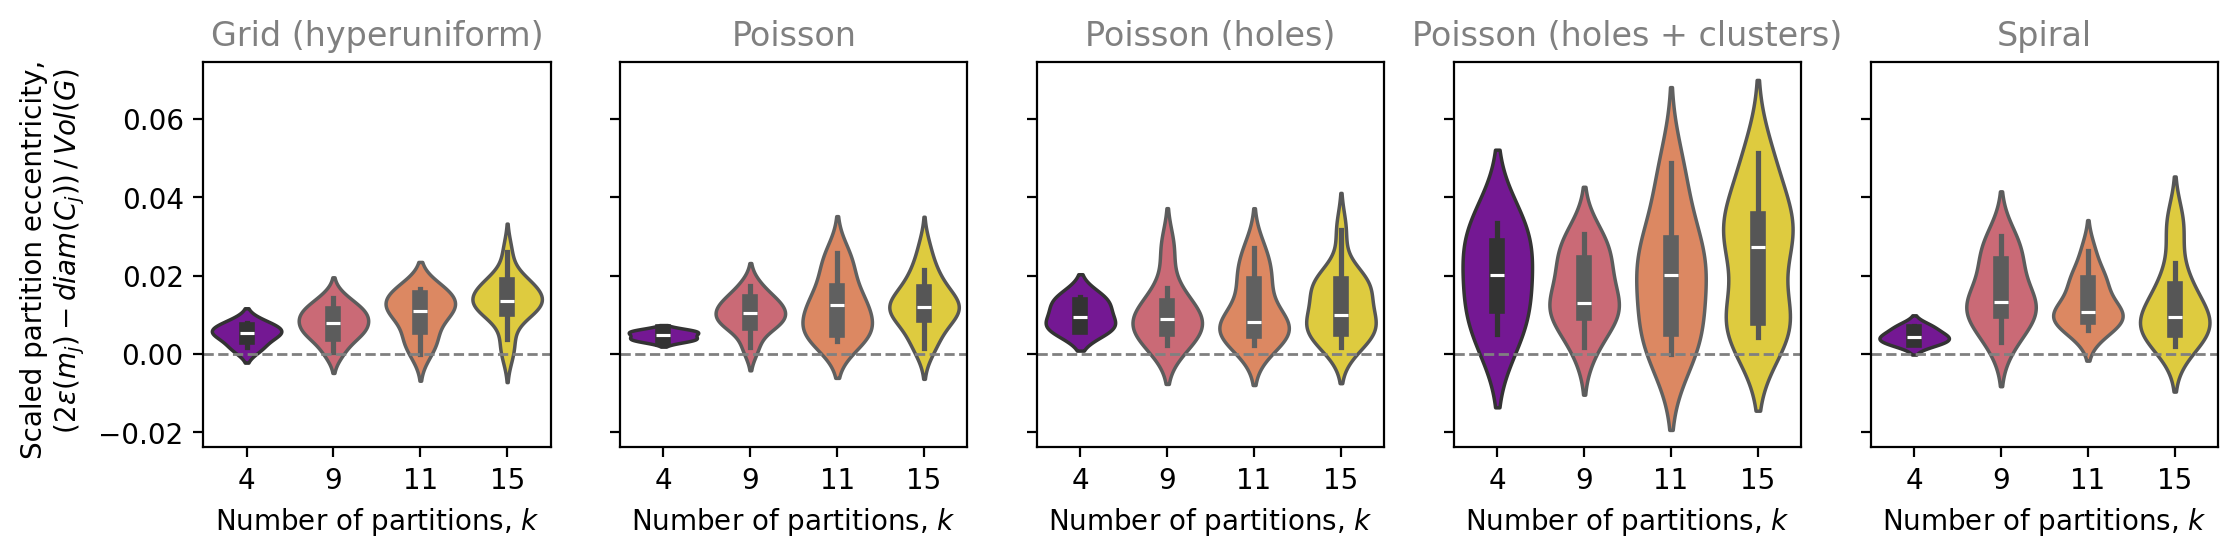

In [9]:
import seaborn as sns

fig,ax=plt.subplots(1,5,figsize=(13,2.5),sharey=True,sharex=True)
networks = [G0,G1,G2,G3,G4]
names = ['Grid (hyperuniform)', 'Poisson', 'Poisson (holes)', 'Poisson (holes + clusters)', 'Spiral']
colors_edge= plt.cm.plasma(np.linspace(0,1,partition_paramters['max_iter']+2))

for i, test in enumerate(target_test_ratio.keys()):
    this_data = target_test_ratio[test]
    #this_vol_dict = {}
    for j, k in enumerate(number_of_partitions):
        
        #these_volumes_normalised = np.log(these_volumes/target_volume)
        these_radii= this_data[k]['community_radii']
       # this_vol_dict[k] = this_data[k]['community_radii']
        
        sns.violinplot(x=[j]*len(these_radii), y=these_radii, ax=ax[i], color=colors_edge[k])
    
    ax[i].set_xticks(range(len(number_of_partitions)))
    ax[i].set_xticklabels(number_of_partitions)
    ax[i].set_title(names[i],color='grey')
    ax[i].set_xlabel('Number of partitions, $k$ ')    
    ax[i].axhline(0, color='grey', linestyle='--', linewidth=1)    
ax[0].set_ylabel('Scaled partition eccentricity, \n $ (2 \\epsilon(m_{j}) - diam(C_{j})) \\, / \\, Vol(G) $')

#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/tiling_tests/figures/partition_ecc_violin.png',bbox_inches='tight',dpi=300)
#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/tiling_tests/figures/partition_ecc_violin.pdf',bbox_inches='tight',dpi=300)

# DEMO leiden

In [10]:
# create a cluster object similar to sklearn
class sknetCluster:
    def __init__(self, knn_graph, communities):
        self.labels_ = communities.labels_
        self.n_clusters_ = len(set(communities.labels_))
        self.modularity_ = skn.clustering.get_modularity(knn_graph,communities.labels_)

communities_1 = skn.clustering.Louvain(resolution=0.1).fit(nx.to_numpy_array(G0,weight='Distance'))
cluster_method_1 = sknetCluster(nx.to_numpy_array(G0,weight='Distance'),communities_1)

communities_2 = skn.clustering.Louvain(resolution=0.4).fit(nx.to_numpy_array(G0,weight='Distance'))
cluster_method_2 = sknetCluster(nx.to_numpy_array(G0,weight='Distance'),communities_2)

communities_3 = skn.clustering.Louvain(resolution=0.7).fit(nx.to_numpy_array(G0,weight='Distance'))
cluster_method_3 = sknetCluster(nx.to_numpy_array(G0,weight='Distance'),communities_3)

communities_4 = skn.clustering.Louvain(resolution=1).fit(nx.to_numpy_array(G0,weight='Distance'))
cluster_method_4 = sknetCluster(nx.to_numpy_array(G0,weight='Distance'),communities_4)



In [11]:
def cluster_volume(G,labels):
    unique_labels = set(labels)
    community_volumes = []

    for i in unique_labels:
        nodes_in_cluster = np.where(labels == i)[0]
        subgraph = G.subgraph(nodes_in_cluster)
        
        internal_volume = subgraph.size(weight='Distance')
        boundary_edges = nx.edge_boundary(G, nodes_in_cluster, data=True)
        boundary_edges_length = 0
        for _, _, data in boundary_edges:
            boundary_edges_length+=data['Distance']
        
        this_volume = internal_volume + boundary_edges_length/2
        
        community_volumes.append(this_volume)
        
    return np.asarray(community_volumes)

In [12]:
volumes_leiden_0 = (cluster_volume(G0, cluster_method_1.labels_) - G0.size(weight='Distance') / cluster_method_1.n_clusters_) / G0.size(weight='Distance') 
volumes_leiden_1 = (cluster_volume(G0, cluster_method_2.labels_)-G0.size(weight='Distance') / cluster_method_2.n_clusters_)   / G0.size(weight='Distance') 
volumes_leiden_2 = (cluster_volume(G0, cluster_method_3.labels_)-G0.size(weight='Distance') / cluster_method_3.n_clusters_)   / G0.size(weight='Distance') 
volumes_leiden_3 = (cluster_volume(G0, cluster_method_4.labels_)-G0.size(weight='Distance') / cluster_method_4.n_clusters_)   / G0.size(weight='Distance') 

all_volumes_leiden = [volumes_leiden_0, volumes_leiden_1, volumes_leiden_2]   
number_of_partitions_leiden = [cluster_method_1.n_clusters_, cluster_method_2.n_clusters_, cluster_method_3.n_clusters_]

/var/folders/mh/z12kkpjj6pjg5_vrjp8t1xd40000gn/T/ipykernel_26761/1343663798.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_4.set_xticklabels(['0.1', '0.4', '0.7'])
/var/folders/mh/z12kkpjj6pjg5_vrjp8t1xd40000gn/T/ipykernel_26761/1343663798.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_5.set_xticklabels(['0.1', '0.4', '0.7'])


Text(0, 0.5, 'y')

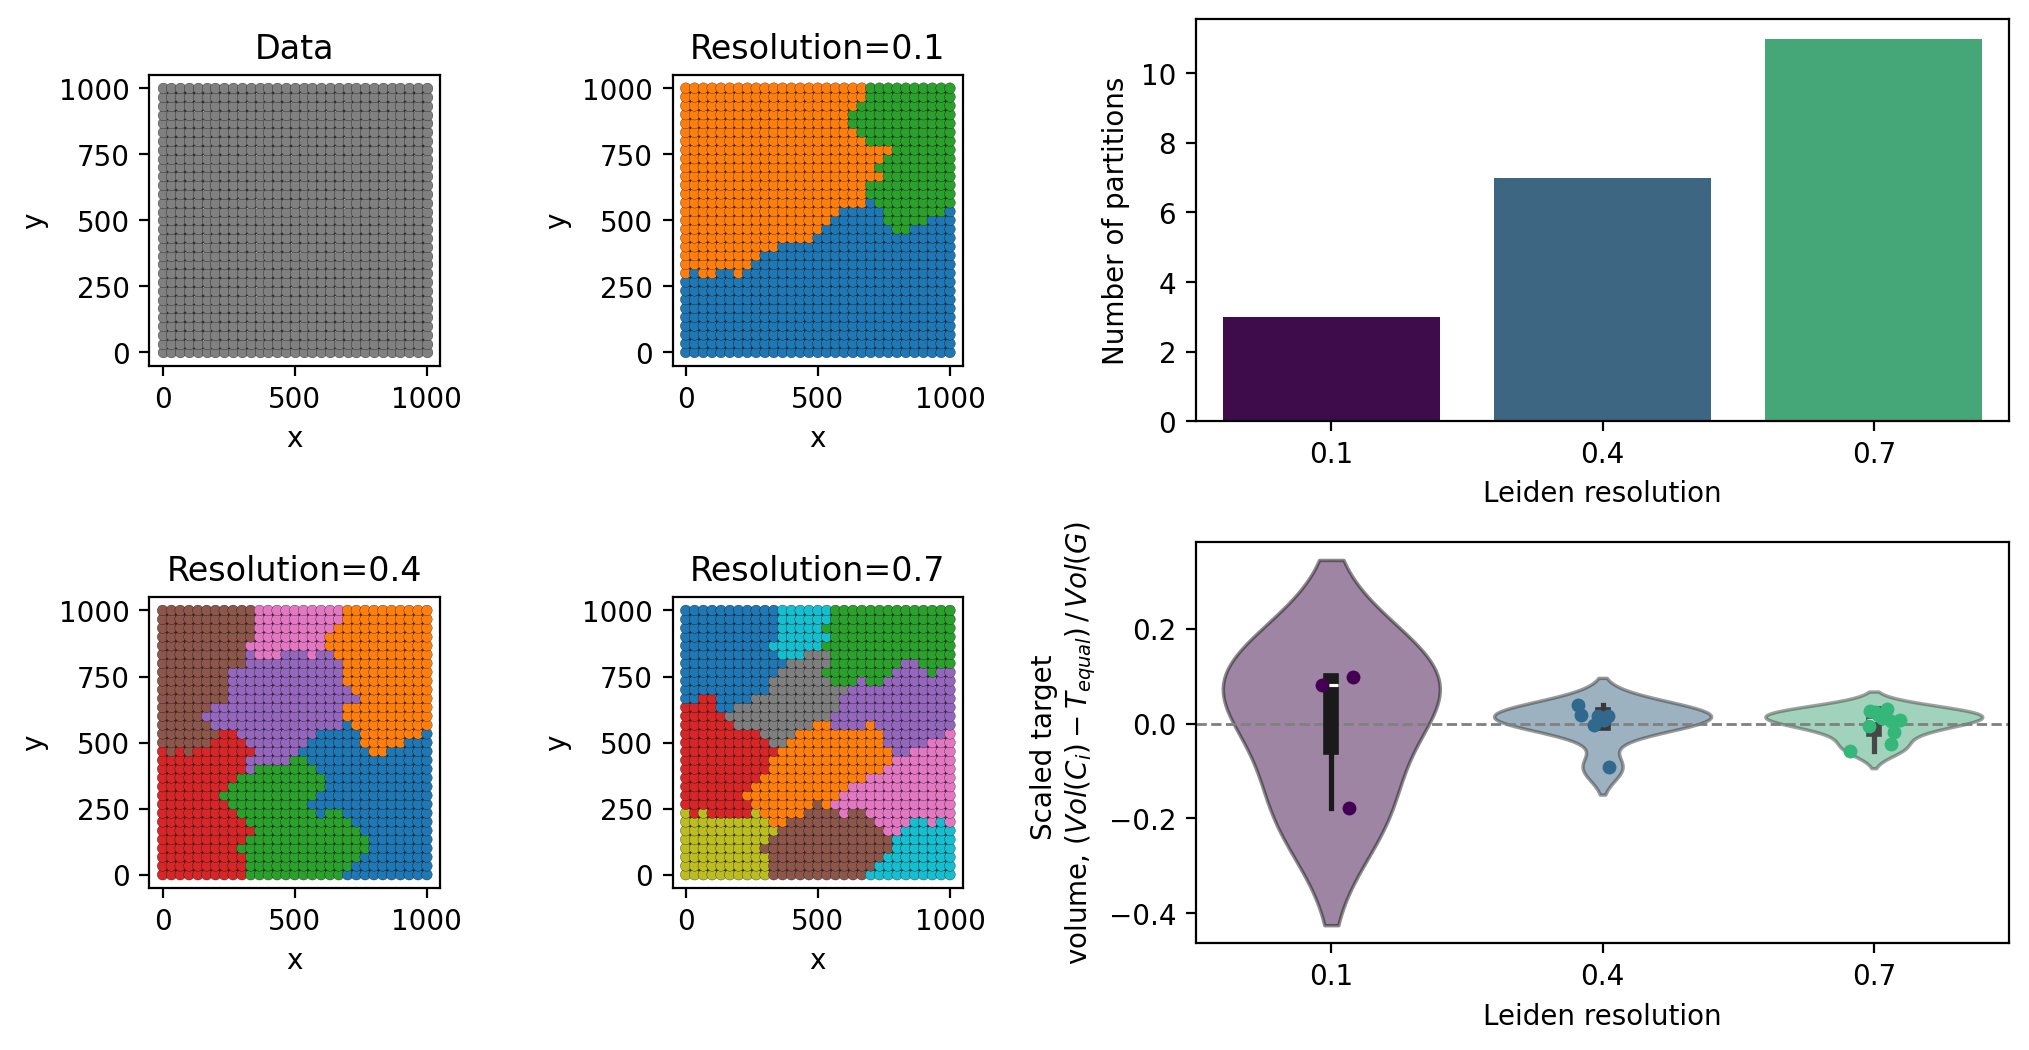

In [13]:
fig = plt.figure(figsize=(12,6))

# Create a 3x3 grid of subplots
grid = plt.GridSpec(2, 4, figure=fig,hspace=0.3,wspace=0.8)

# Central scatter plot
ax_0 = fig.add_subplot(grid[0,0])
ax_1 = fig.add_subplot(grid[0,1])
ax_2 = fig.add_subplot(grid[1,0])
ax_3 = fig.add_subplot(grid[1,1])

ax_4 = fig.add_subplot(grid[1,2:])
ax_4.axhline(0, color='grey', linestyle='--', linewidth=1)  
colors_edge= plt.cm.viridis(np.linspace(0,1,4))
for i in range(len(all_volumes_leiden)):
    sns.violinplot(x=[i]*len(all_volumes_leiden[i]), y=all_volumes_leiden[i], ax=ax_4, color=colors_edge[i],alpha=0.5)
    sns.stripplot(x=[i]*len(all_volumes_leiden[i]), y=all_volumes_leiden[i], ax=ax_4, color=colors_edge[i])
    
ax_4.set_xticklabels(['0.1', '0.4', '0.7'])
ax_4.set_xlabel('Leiden resolution')
ax_4.set_ylabel('Scaled target \nvolume, $(Vol(C_{i}) - T_{equal}) \\, / \\, Vol(G)$') 


ax_5 = fig.add_subplot(grid[0,2:])
ax_5.axhline(0, color='grey', linestyle='--', linewidth=1)  
colors_edge= plt.cm.viridis(np.linspace(0,1,4))
for i in range(len(all_volumes_leiden)):
    sns.barplot(x=[i], y=number_of_partitions_leiden[i], ax=ax_5, color=colors_edge[i],alpha=1)

ax_5.set_xticklabels(['0.1', '0.4', '0.7'])
ax_5.set_xlabel('Leiden resolution')

ax_5.set_ylabel('Number of partitions')

sn.utils.add_node_labels(G0,cluster_method_1.labels_,'labels_1')
sn.utils.add_node_labels(G0,cluster_method_2.labels_,'labels_2')
sn.utils.add_node_labels(G0,cluster_method_3.labels_,'labels_3')

sn.utils.plot_spatial_network(G0,ax=ax_0,**visualise_paras)
sn.utils.plot_spatial_network(G0,node_label_name='labels_1',ax=ax_1,**visualise_paras)
sn.utils.plot_spatial_network(G0,node_label_name='labels_2',ax=ax_2,**visualise_paras)
sn.utils.plot_spatial_network(G0,node_label_name='labels_3',ax=ax_3,**visualise_paras)

ax_0.set_title('Data')
ax_1.set_title(f'Resolution={0.1}')
ax_2.set_title(f'Resolution={0.4}')
ax_3.set_title(f'Resolution={0.7}')

ax_0.set_xlabel('x')
ax_0.set_ylabel('y')

ax_1.set_xlabel('x')
ax_1.set_ylabel('y')

ax_2.set_xlabel('x')
ax_2.set_ylabel('y')

ax_3.set_xlabel('x')
ax_3.set_ylabel('y')
#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/tiling_tests/figures/leiden_comparison.png',bbox_inches='tight',dpi=300)
#fig.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/tiling_tests/figures/leiden_comparison.pdf',bbox_inches='tight',dpi=300)
